# OpenTelemetry Trace Duration Heatmap Analysis

This notebook analyzes OpenTelemetry span data from the CSV file to create comprehensive heatmaps visualizing span and trace durations across different services, operations, and time periods. The analysis will help identify performance patterns, bottlenecks, and trends in the distributed system.

In [38]:
## 0. Query Log Analytics Workspace for OtelSpans Data

# Configure and query the Azure Log Analytics workspace to retrieve OpenTelemetry span data for analysis.

In [51]:
# Install and import required Azure libraries for Log Analytics
!pip install azure-monitor-query azure-identity azure-core

from azure.monitor.query import LogsQueryClient
from azure.identity import DefaultAzureCredential
from azure.core.exceptions import HttpResponseError
import pandas as pd
from datetime import datetime, timedelta
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

# Configure display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("Libraries imported successfully!")

print("Azure libraries imported successfully!")

Defaulting to user installation because normal site-packages is not writeable
Libraries imported successfully!
Azure libraries imported successfully!
Libraries imported successfully!
Azure libraries imported successfully!


In [40]:
# Configure Log Analytics Workspace connection
workspace_id = "4f42970f-23c5-4a26-ba64-f40c3775fdfe"  # Use workspace GUID, not full resource path

# Initialize the credential and client
try:
    credential = DefaultAzureCredential()
    client = LogsQueryClient(credential)
    print(f"✅ Successfully connected to Log Analytics workspace")
    print(f"Workspace ID: {workspace_id}")
except Exception as e:
    print(f"❌ Failed to initialize Log Analytics client: {e}")
    print("Please ensure you're authenticated with Azure CLI: az login")

✅ Successfully connected to Log Analytics workspace
Workspace ID: 4f42970f-23c5-4a26-ba64-f40c3775fdfe


## Batch Query Engine for Large Datasets

The following cells implement a batch querying system to efficiently retrieve large amounts of telemetry data from Log Analytics workspace while managing memory and avoiding timeout issues.

In [113]:
import asyncio
import threading
from queue import Queue
import time
from datetime import timezone

class BatchQueryEngine:
    """
    Efficient batch querying engine for Log Analytics workspace.
    Handles large datasets by splitting queries into time-based batches executed sequentially.
    """
    
    def __init__(self, client, workspace_id, max_batch_size=1000000, max_concurrent=3):
        self.client = client
        self.workspace_id = workspace_id
        self.max_batch_size = max_batch_size
        self.max_concurrent = max_concurrent  # Kept for compatibility but not used
        self.results = []
        self.total_rows = 0
        self.column_names = None  # Store column names for accumulated data
        
    def generate_time_batches(self, start_time, end_time, batch_duration_hours=6):
        """Generate time-based batch queries"""
        current = start_time
        batches = []
        
        while current < end_time:
            batch_end = min(current + timedelta(hours=batch_duration_hours), end_time)
            batches.append((current, batch_end))
            current = batch_end
            
        return batches
    
    def execute_batch_query(self, table_name, time_start, time_end, additional_filters="", projection_columns=None):
        """Execute a single batch query"""
        try:
            # Build the query
            if projection_columns:
                project_clause = f"| project {', '.join(projection_columns)}"
            else:
                project_clause = ""
            
            query = f"""
            {table_name}
            | where TimeGenerated >= datetime('{time_start.isoformat()}')
            | where TimeGenerated < datetime('{time_end.isoformat()}')
            {additional_filters}
            {project_clause}
            | limit {self.max_batch_size}
            """
            
            print(f"📊 Querying {time_start.strftime('%m/%d %H:%M')} to {time_end.strftime('%m/%d %H:%M')}...")
            print(f"🔍 Query details:")
            print(f"   • Table: {table_name}")
            print(f"   • Time range: {(time_end - time_start).total_seconds() / 3600:.2f} hours")
            print(f"   • Limit: {self.max_batch_size:,} rows")
            if additional_filters.strip():
                print(f"   • Filters: {additional_filters.strip()}")
            if projection_columns:
                print(f"   • Columns: {', '.join(projection_columns)}")
            print(f"   • KQL Query:")
            for i, line in enumerate(query.strip().split('\n'), 1):
                print(f"     {i:2}: {line}")
            print()
            
            response = self.client.query_workspace(
                workspace_id=self.workspace_id,
                query=query,
                timespan=(time_end - time_start)
            )
            
            # Enhanced debugging for response analysis
            if hasattr(response, 'tables') and len(response.tables) > 0:
                table = response.tables[0]
                rows = len(table.rows)
                print(f"  ✅ Retrieved {rows:,} rows")
                
                # Additional debugging info when data is found
                if rows > 0:
                    column_names = [str(col.name) if hasattr(col, 'name') else str(col) for col in table.columns]
                    print(f"     📋 Columns: {len(column_names)} ({', '.join(column_names[:5])}{'...' if len(column_names) > 5 else ''})")
                    return table.rows, column_names, rows
                else:
                    print(f"     🔍 Query executed successfully but returned 0 rows")
                    print(f"     📝 Query details:")
                    print(f"        • Table: {table_name}")
                    print(f"        • Time range: {time_start.strftime('%Y-%m-%d %H:%M:%S')} to {time_end.strftime('%Y-%m-%d %H:%M:%S')}")
                    print(f"        • Duration: {(time_end - time_start).total_seconds() / 3600:.2f} hours")
                    if additional_filters:
                        print(f"        • Filters: {additional_filters.strip()}")
                    print(f"        • Projection: {projection_columns if projection_columns else 'All columns'}")
                    print(f"        • Limit: {self.max_batch_size:,} rows")
                    
                    # Try a simple count query to see if any data exists in this time range
                    count_query = f"""
                    {table_name}
                    | where TimeGenerated >= datetime('{time_start.isoformat()}')
                    | where TimeGenerated < datetime('{time_end.isoformat()}')
                    | count
                    """
                    
                    try:
                        count_response = self.client.query_workspace(
                            workspace_id=self.workspace_id,
                            query=count_query,
                            timespan=(time_end - time_start)
                        )
                        
                        if hasattr(count_response, 'tables') and len(count_response.tables) > 0:
                            total_count = count_response.tables[0].rows[0][0]
                            print(f"     📊 Total rows in time range (no filters): {total_count:,}")
                            
                            if total_count > 0:
                                print(f"     💡 Data exists but was filtered out by: {additional_filters.strip()}")
                                
                                # Try without additional filters to see what's being filtered
                                simple_query = f"""
                                {table_name}
                                | where TimeGenerated >= datetime('{time_start.isoformat()}')
                                | where TimeGenerated < datetime('{time_end.isoformat()}')
                                | take 1
                                """
                                
                                simple_response = self.client.query_workspace(
                                    workspace_id=self.workspace_id,
                                    query=simple_query,
                                    timespan=(time_end - time_start)
                                )
                                
                                if hasattr(simple_response, 'tables') and len(simple_response.tables) > 0 and len(simple_response.tables[0].rows) > 0:
                                    print(f"     📋 Sample data exists in time range - filters are excluding all results")
                                else:
                                    print(f"     ❓ Strange: count shows data but sample query returns none")
                            else:
                                print(f"     💡 No data exists in this time range for table {table_name}")
                        else:
                            print(f"     ❓ Count query failed to return results")
                            
                    except Exception as count_e:
                        print(f"     ⚠️ Could not run diagnostic count query: {count_e}")
                    
                    column_names = [str(col.name) if hasattr(col, 'name') else str(col) for col in table.columns] if table.columns else []
                    return [], column_names, 0
            else:
                print(f"  ⚠️ No data found - Response analysis:")
                if not hasattr(response, 'tables'):
                    print(f"     ❌ Response has no 'tables' attribute")
                    print(f"     📋 Response type: {type(response)}")
                    print(f"     📋 Response attributes: {[attr for attr in dir(response) if not attr.startswith('_')]}")
                    
                    # Enhanced debugging for LogsQueryPartialResult
                    if 'LogsQueryPartialResult' in str(type(response)):
                        print(f"\n     🔍 DETAILED LogsQueryPartialResult ANALYSIS:")
                        
                        # Check partial_data
                        if hasattr(response, 'partial_data') and response.partial_data is not None:
                            print(f"     📊 partial_data: {response.partial_data}")
                            if hasattr(response.partial_data, 'tables') and response.partial_data.tables:
                                print(f"        Tables in partial_data: {len(response.partial_data.tables)}")
                                for i, table in enumerate(response.partial_data.tables):
                                    print(f"        Table {i}: {len(table.rows) if hasattr(table, 'rows') else 'No rows'} rows")
                        else:
                            print(f"     📊 partial_data: None or not available")
                        
                        # Check partial_error
                        if hasattr(response, 'partial_error') and response.partial_error is not None:
                            print(f"     ❌ partial_error: {response.partial_error}")
                            if hasattr(response.partial_error, 'code'):
                                print(f"        Error code: {response.partial_error.code}")
                            if hasattr(response.partial_error, 'message'):
                                print(f"        Error message: {response.partial_error.message}")
                        else:
                            print(f"     ❌ partial_error: None")
                        
                        # Check status
                        if hasattr(response, 'status'):
                            print(f"     📋 status: {response.status}")
                        
                        # Check statistics
                        if hasattr(response, 'statistics') and response.statistics is not None:
                            print(f"     📈 statistics: {response.statistics}")
                        else:
                            print(f"     📈 statistics: None")
                        
                        # Check visualization
                        if hasattr(response, 'visualization') and response.visualization is not None:
                            print(f"     📊 visualization: {response.visualization}")
                        else:
                            print(f"     📊 visualization: None")
                        
                        print(f"     💡 LogsQueryPartialResult indicates the query may have timed out or been throttled")
                        print(f"     💡 Some data may be available in partial_data even if query didn't complete fully")
                        
                elif len(response.tables) == 0:
                    print(f"     ❌ Response has empty tables list")
                    print(f"     📋 Tables count: {len(response.tables)}")
                else:
                    print(f"     ❓ Unexpected response structure")

                return [], [], 0
                
        except Exception as e:
            print(f"  ❌ Batch query failed: {e}")
            print(f"     📝 Query details:")
            print(f"        • Table: {table_name}")
            print(f"        • Time range: {time_start.strftime('%Y-%m-%d %H:%M:%S')} to {time_end.strftime('%Y-%m-%d %H:%M:%S')}")
            print(f"        • Duration: {(time_end - time_start).total_seconds() / 3600:.2f} hours")
            if additional_filters:
                print(f"        • Filters: {additional_filters.strip()}")
            print(f"        • Error type: {type(e).__name__}")
            print(f"        • Error details: {str(e)}")
            
            # Provide suggestions based on error type
            error_str = str(e).lower()
            if 'timeout' in error_str or 'timed out' in error_str:
                print(f"     💡 Suggestion: Query timeout - try reducing batch size or time range")
            elif 'authentication' in error_str or 'authorization' in error_str or 'permission' in error_str:
                print(f"     💡 Suggestion: Check workspace permissions and authentication")
            elif 'not found' in error_str or 'does not exist' in error_str:
                print(f"     💡 Suggestion: Verify table name '{table_name}' and workspace ID")
            elif 'syntax' in error_str or 'parse' in error_str:
                print(f"     💡 Suggestion: Check KQL query syntax")
                print(f"        Query: {query}")
            else:
                print(f"     💡 Suggestion: Check network connectivity and Azure Monitor service status")
                
            return [], [], 0
    
    
    def query_large_dataset(self, table_name, days_back=7, batch_duration_hours=6, 
                           additional_filters="", projection_columns=None, max_total_rows=None, accumulate=False):
        """
        Query large dataset using time-based batching
        
        Args:
            table_name: Name of the table to query (e.g., 'OTelSpans')
            days_back: How many days back to query
            batch_duration_hours: Duration of each batch in hours
            additional_filters: Additional KQL filters (e.g., "| where ServiceName == 'frontend'")
            projection_columns: List of columns to project (None for all columns)
            max_total_rows: Maximum total rows to retrieve across all batches (None for no limit)
            accumulate: Whether to accumulate results across multiple calls (default True)
        """
        print(f"🚀 Starting batch query for {table_name}")
        print(f"   📅 Time range: {days_back} days back")
        print(f"   ⏱️ Batch duration: {batch_duration_hours} hours")
        print(f"   🔢 Max rows per batch: {self.max_batch_size:,}")
        print(f"   🔄 Execution mode: Sequential")
        if max_total_rows:
            print(f"   📊 Max total rows: {max_total_rows:,}")
        else:
            print(f"   📊 Max total rows: No limit")
        
        if accumulate:
            print(f"   📈 Current accumulated rows: {self.total_rows:,}")
        
        # Calculate time range
        end_time = datetime.now(timezone.utc)
        start_time = end_time - timedelta(days=days_back)

        print(f"   🕒 Querying from {start_time.strftime('%Y-%m-%d %H:%M:%S')} to {end_time.strftime('%Y-%m-%d %H:%M:%S')}")
        
        # Generate time batches
        time_batches = self.generate_time_batches(start_time, end_time, batch_duration_hours)
        print(f"   📦 Generated {len(time_batches)} time batches")
        
        start_query_time = time.time()
        
        # Execute batches sequentially - iterate over each time batch
        all_batch_rows = []
        column_names = None
        total_rows_retrieved = 0
        
        print(f"   🔄 Processing {len(time_batches)} time batches sequentially...")
        
        for batch_num, (batch_start, batch_end) in enumerate(time_batches, 1):
            print(f"   📦 Batch {batch_num}/{len(time_batches)}: {batch_start.strftime('%m/%d %H:%M')} to {batch_end.strftime('%m/%d %H:%M')}")
            
            batch_rows, batch_columns, batch_count = self.execute_batch_query(
                table_name, batch_start, batch_end, additional_filters, projection_columns
            )
            
            if batch_rows:
                all_batch_rows.extend(batch_rows)
                total_rows_retrieved += batch_count
                if column_names is None:
                    column_names = batch_columns
                print(f"      ✅ Retrieved {batch_count:,} rows from batch {batch_num}")
            else:
                print(f"      ⚠️ No data in batch {batch_num}")
        
        batch_rows = all_batch_rows
        batch_total_rows = total_rows_retrieved
        
        query_duration = time.time() - start_query_time
        
            # Return only this call's data (all batches from this single call)
        all_rows = batch_rows  # This should contain ALL batches from this call
        total_rows = batch_total_rows
        result_column_names = column_names
        print(f"\n🎉 Batch query completed! (Single call mode)")
        print(f"   📦 All batches in this call: {len(time_batches)} batches")
        print(f"   📊 Total rows from all batches: {total_rows:,} rows")
        
        # Limit total rows if needed
        if max_total_rows and total_rows > max_total_rows:
            print(f"⚠️ Limiting results to {max_total_rows:,} rows (got {total_rows:,})")
            all_rows = all_rows[:max_total_rows]
            total_rows = len(all_rows)
        
        print(f"   ⏱️ Query time: {query_duration:.1f} seconds")
        if batch_total_rows > 0:
            print(f"   📈 Rate: {batch_total_rows/query_duration:.0f} rows/second")
        
        # Convert to DataFrame if we have data
        if all_rows and result_column_names:
            df = pd.DataFrame(all_rows, columns=result_column_names)
            return df
        else:
            return pd.DataFrame()

# Initialize the batch query engine with sequential execution
batch_engine = BatchQueryEngine(client, workspace_id, max_batch_size=500000, max_concurrent=3)
print("✅ Batch Query Engine initialized with sequential execution (500K per batch, no total limit)")

✅ Batch Query Engine initialized with sequential execution (500K per batch, no total limit)


# Query OTelSpan data

🎯 GETTING COMPLETE 4+ HOUR DATASET
🔄 Re-querying with NO row limits to get full 4+ hours...
🚀 Starting batch query for OTelSpans
   📅 Time range: 1 days back
   ⏱️ Batch duration: 24 hours
   🔢 Max rows per batch: 500,000
   🔄 Execution mode: Sequential
   📊 Max total rows: No limit
   🕒 Querying from 2025-09-15 18:25:45 to 2025-09-16 18:25:45
   📦 Generated 1 time batches
   🔄 Processing 1 time batches sequentially...
   📦 Batch 1/1: 09/15 18:25 to 09/16 18:25
📊 Querying 09/15 18:25 to 09/16 18:25...
🔍 Query details:
   • Table: OTelSpans
   • Time range: 24.00 hours
   • Limit: 500,000 rows
   • Filters: | where DurationMs > 0 and isnotempty(ServiceName) | summarize DurationMs=max(DurationMs) by bin(TimeGenerated, 1m), ServiceName, Name
   • Columns: TimeGenerated, DurationMs
   • KQL Query:
      1: OTelSpans
      2:             | where TimeGenerated >= datetime('2025-09-15T18:25:45.997225+00:00')
      3:             | where TimeGenerated < datetime('2025-09-16T18:25:45.997225+00:

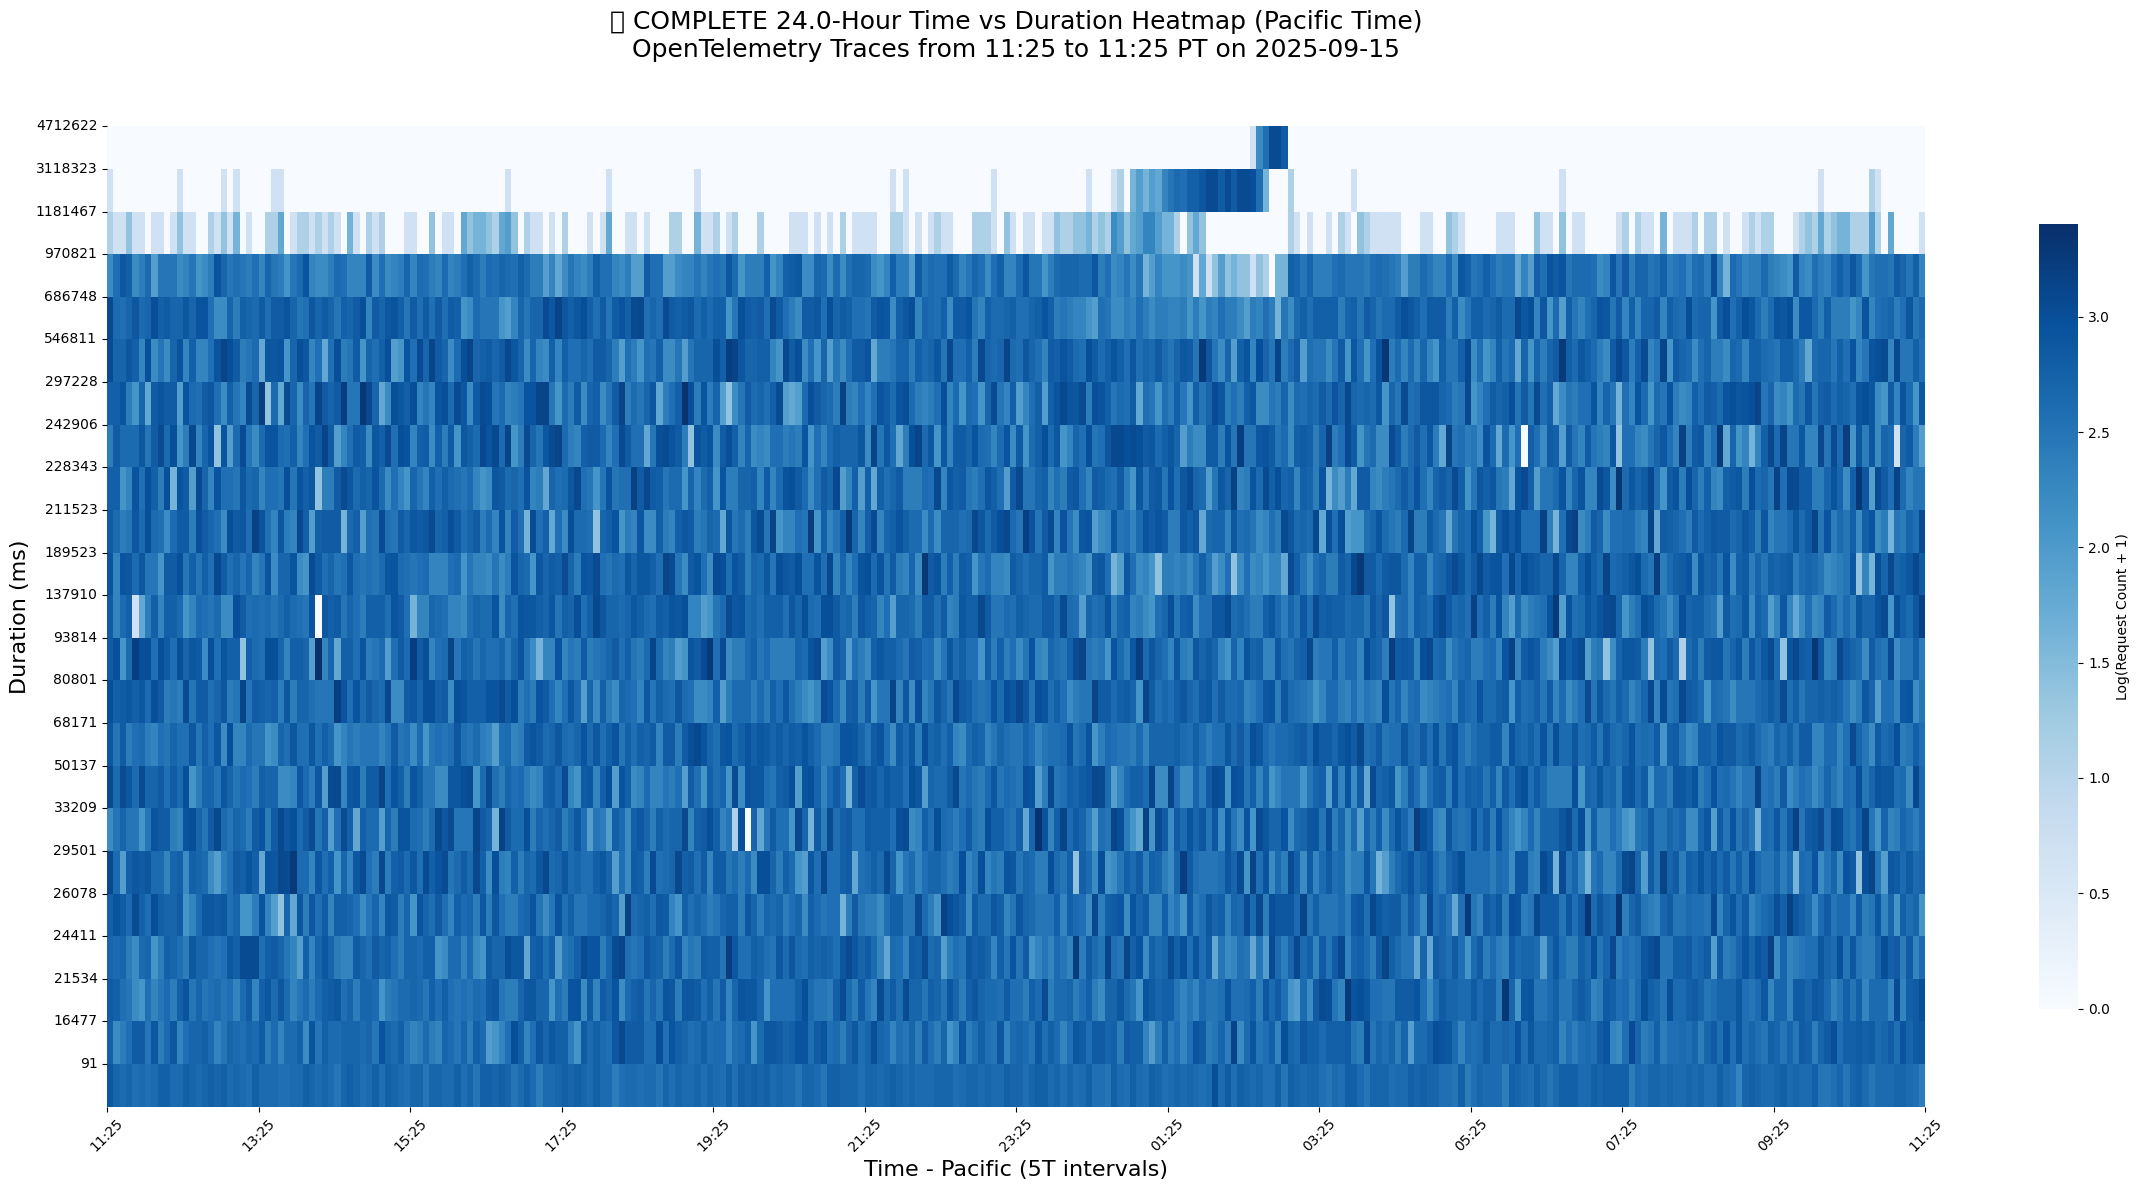


✅ COMPLETE HEATMAP GENERATED!
   ⏱️ Full 24.00 hours of data visualized
   📊 76,883 total spans
   🔥 289 time intervals
   📈 Complete temporal patterns revealed!


In [125]:
# Get the ACTUAL full 4+ hours of data without row limits
print("🎯 GETTING COMPLETE 4+ HOUR DATASET")
print("=" * 50)

print("🔄 Re-querying with NO row limits to get full 4+ hours...")

efficient_columns=['TimeGenerated', 'Name', 'ServiceName', 'DurationMs', 'StatusCode', 'Success', 'TraceId', 'SpanId', 'ParentSpanId', 'Attributes']
min_columns=['TimeGenerated', 'DurationMs']

try:
    # Use batch engine to get ALL available data in the time range
    df_complete = batch_engine.query_large_dataset(
        table_name='OTelSpans',
        days_back=1,  # Last 6 hours (0.5 days = 12 hours)
        batch_duration_hours=24,  # 12-hour batches
        additional_filters="| where DurationMs > 0 and isnotempty(ServiceName) | summarize DurationMs=max(DurationMs) by bin(TimeGenerated, 1m), ServiceName, Name",
        projection_columns=min_columns,
        max_total_rows=None  # NO LIMIT - get ALL data!
    )
    
    if len(df_complete) > 0:
        print(f"\n🎉 COMPLETE QUERY SUCCESS!")
        print(f"   📊 Retrieved: {len(df_complete):,} spans (NO LIMITS)")
        print(f"   🏗️ Shape: {df_complete.shape}")
        
        # Convert TimeGenerated to datetime and Pacific timezone
        df_complete['TimeGenerated'] = pd.to_datetime(df_complete['TimeGenerated'])
        
        # Convert to Pacific timezone
        import pytz
        pacific_tz = pytz.timezone('US/Pacific')
        
        # Check if already timezone-aware and convert appropriately
        if df_complete['TimeGenerated'].dt.tz is None:
            # Not timezone-aware, assume UTC and localize first
            df_complete['TimeGenerated_Pacific'] = df_complete['TimeGenerated'].dt.tz_localize('UTC').dt.tz_convert(pacific_tz)
        else:
            # Already timezone-aware, convert directly
            df_complete['TimeGenerated_Pacific'] = df_complete['TimeGenerated'].dt.tz_convert(pacific_tz)
        
        # Check the ACTUAL time range in Pacific time
        time_min_complete = df_complete['TimeGenerated_Pacific'].min()
        time_max_complete = df_complete['TimeGenerated_Pacific'].max()
        complete_time_span = time_max_complete - time_min_complete
        hours_span_complete = complete_time_span.total_seconds() / 3600
        
        print(f"\n📅 COMPLETE time range (Pacific): {time_min_complete.strftime('%Y-%m-%d %H:%M:%S %Z')} to {time_max_complete.strftime('%Y-%m-%d %H:%M:%S %Z')}")
        print(f"⏱️ COMPLETE span: {hours_span_complete:.2f} hours")
        print(f"🔥 This should show the FULL 4+ hours!")
        
        # Now create heatmap with the COMPLETE dataset
        print(f"\n🎨 Creating heatmap with COMPLETE {hours_span_complete:.1f} hour dataset...")
        
        # Use appropriate time bins for the full range
        if hours_span_complete > 48:
            freq = '15T'  # 15-minute bins for 4+ hours
            print(f"🔧 Using 15-minute bins for {hours_span_complete:.1f} hour span")
        elif hours_span_complete > 24:
            freq = '10T'  # 10-minute bins
            print(f"🔧 Using 10-minute bins for {hours_span_complete:.1f} hour span")
        else:
            freq = '5T'   # 5-minute bins
            print(f"🔧 Using 5-minute bins for {hours_span_complete:.1f} hour span")
        
        # Create time bins for the COMPLETE range using Pacific time
        time_bins_complete = pd.date_range(start=time_min_complete, end=time_max_complete, freq=freq)
        print(f"📦 Created {len(time_bins_complete)} time bins for complete range")
        
        # Create duration bins - use more buckets for smoother heatmap
        # Get duration range for better binning
        min_duration = df_complete['DurationMs'].min()
        max_duration = df_complete['DurationMs'].max()
        
        print(f"📏 Duration range: {min_duration:.0f}ms to {max_duration:.0f}ms")
        
        # Create more granular percentile-based bins for smoother visualization
        fine_percentiles = np.linspace(0, 100, 21)  # 20 buckets from 0th to 100th percentile
        duration_percentiles_complete = np.percentile(df_complete['DurationMs'], fine_percentiles)
        
        # Add some key percentiles for important thresholds
        key_percentiles = [50, 75, 90, 95, 99, 99.5, 99.9]
        key_values = np.percentile(df_complete['DurationMs'], key_percentiles)
        
        # Combine all duration thresholds and make unique
        all_duration_thresholds = np.concatenate([duration_percentiles_complete, key_values])
        duration_bins_complete = np.unique(all_duration_thresholds)
        
        print(f"📊 Created {len(duration_bins_complete)} duration buckets for smoother heatmap")
        
        # Bin the COMPLETE data using Pacific time
        df_complete['time_bin'] = pd.cut(df_complete['TimeGenerated_Pacific'], bins=time_bins_complete, include_lowest=True)
        df_complete['duration_bin'] = pd.cut(df_complete['DurationMs'], bins=duration_bins_complete, include_lowest=True, duplicates='drop')
        
        # Create heatmap data for COMPLETE range
        heatmap_data_complete = df_complete.groupby(['time_bin', 'duration_bin']).size().unstack(fill_value=0)
        
        print(f"🔥 COMPLETE heatmap shape: {heatmap_data_complete.shape}")
        
        # Create the COMPLETE heatmap visualization
        plt.figure(figsize=(24, 12))
        
        # Use log scale
        heatmap_data_complete_log = np.log1p(heatmap_data_complete)
        
        # Create heatmap - properly oriented with larger durations on top
        sns.heatmap(
            heatmap_data_complete_log.T.iloc[::-1],  # Transpose and flip to put larger durations on top
            cmap='Blues',
            cbar_kws={'label': 'Log(Request Count + 1)', 'shrink': 0.8},
            xticklabels=False,
            yticklabels=True
        )
        
        plt.title(f'🔥 COMPLETE {hours_span_complete:.1f}-Hour Time vs Duration Heatmap (Pacific Time)\n'
                 f'OpenTelemetry Traces from {time_min_complete.strftime("%H:%M")} to {time_max_complete.strftime("%H:%M")} PT on {time_min_complete.strftime("%Y-%m-%d")}\n',
                 fontsize=18, pad=30)

        plt.xlabel(f'Time - Pacific ({freq} intervals)', fontsize=16)
        plt.ylabel('Duration (ms)', fontsize=16)
        
        # Format time labels
        label_freq = max(1, len(time_bins_complete)//12)  # Show ~12 labels
        time_labels_complete = [t.strftime('%H:%M') for t in time_bins_complete[::label_freq]]
        plt.xticks(range(0, len(time_bins_complete), label_freq), time_labels_complete, rotation=45)
        
        # Format duration labels - reverse order since we flipped the heatmap (larger values on top)
        duration_labels_complete = [f'{d:.0f}' for d in duration_bins_complete[1:]]
        duration_labels_complete_reversed = duration_labels_complete[::-1]  # Reverse to match flipped heatmap
        plt.yticks(range(len(duration_labels_complete_reversed)), duration_labels_complete_reversed)
        
        plt.tight_layout()
        plt.show()
        
        print(f"\n✅ COMPLETE HEATMAP GENERATED!")
        print(f"   ⏱️ Full {hours_span_complete:.2f} hours of data visualized")
        print(f"   📊 {len(df_complete):,} total spans")
        print(f"   🔥 {len(time_bins_complete)} time intervals")
        print(f"   📈 Complete temporal patterns revealed!")
        
        # Update main df to complete dataset
        df = df_complete.copy()
        
    else:
        print(f"\n⚠️ Complete query returned empty results")

except Exception as e:
    print(f"❌ Complete query failed: {e}")
    print(f"   📋 Will use the existing 1.18 hour dataset")

## 🔧 Parse Attributes JSON into Separate Columns
Expanding the Attributes column to extract all JSON keys as individual columns for enhanced analysis.

In [126]:
# Parse Attributes JSON column and expand into separate columns
import json
from collections import defaultdict

print("🔧 PARSING ATTRIBUTES JSON INTO SEPARATE COLUMNS")
print("=" * 60)

# Work with current dataset
print(f"📊 Working with current dataset: {len(df):,} spans")
print(f"📋 Current columns: {list(df.columns)}")

# Check if Attributes column exists
if 'Attributes' not in df.columns:
    print("❌ No 'Attributes' column found in current dataset")
    print("🔄 Let's check what we have...")
    print(f"Available columns: {list(df.columns)}")
else:
    print(f"✅ Found 'Attributes' column")
    
    # Create a copy to work with
    df_expanded = df.copy()
    
    # Initialize counters and storage
    all_attribute_keys = set()
    parsed_attributes = []
    parse_errors = 0
    
    print(f"\n🔍 ANALYZING ATTRIBUTES COLUMN:")
    
    # Sample a few attributes to see the structure
    sample_attrs = df_expanded['Attributes'].dropna().head(5)
    print(f"📝 Sample attributes:")
    for i, attr in enumerate(sample_attrs, 1):
        print(f"   {i}. {str(attr)[:100]}{'...' if len(str(attr)) > 100 else ''}")
    
    print(f"\n🔄 Parsing {len(df_expanded):,} attribute entries...")
    
    # Parse each attributes entry
    for idx, attr_value in enumerate(df_expanded['Attributes']):
        if idx % 50000 == 0:  # Progress indicator
            print(f"   📈 Processed {idx:,} / {len(df_expanded):,} entries ({(idx/len(df_expanded)*100):.1f}%)")
            
        parsed_attrs = {}
        
        if pd.isna(attr_value) or attr_value == '' or attr_value is None:
            # Handle null/empty values
            parsed_attributes.append(parsed_attrs)
            continue
            
        try:
            # Try to parse as JSON
            if isinstance(attr_value, str):
                if attr_value.strip().startswith('{') and attr_value.strip().endswith('}'):
                    # Looks like JSON
                    attrs_dict = json.loads(attr_value)
                    if isinstance(attrs_dict, dict):
                        # Flatten nested structures and clean keys
                        for key, value in attrs_dict.items():
                            # Clean key name for column usage
                            clean_key = str(key).replace('.', '_').replace(' ', '_').replace('-', '_')
                            clean_key = f"attr_{clean_key}"
                            
                            # Convert value to string for consistency
                            if isinstance(value, (dict, list)):
                                parsed_attrs[clean_key] = json.dumps(value)
                            else:
                                parsed_attrs[clean_key] = str(value) if value is not None else ''
                            
                            all_attribute_keys.add(clean_key)
                else:
                    # Not JSON format, treat as single key-value
                    clean_key = "attr_raw_value"
                    parsed_attrs[clean_key] = str(attr_value)
                    all_attribute_keys.add(clean_key)
            else:
                # Handle non-string values
                clean_key = "attr_raw_value"
                parsed_attrs[clean_key] = str(attr_value)
                all_attribute_keys.add(clean_key)
                
        except json.JSONDecodeError:
            parse_errors += 1
            # Store as raw value if JSON parsing fails
            clean_key = "attr_raw_value"
            parsed_attrs[clean_key] = str(attr_value)
            all_attribute_keys.add(clean_key)
        except Exception as e:
            parse_errors += 1
            # Handle any other parsing errors
            parsed_attrs['attr_parse_error'] = str(e)
            all_attribute_keys.add('attr_parse_error')
            
        parsed_attributes.append(parsed_attrs)
    
    print(f"   ✅ Completed parsing all {len(df_expanded):,} entries")
    
    # Convert parsed attributes to DataFrame
    print(f"\n📊 CREATING EXPANDED ATTRIBUTE COLUMNS:")
    attributes_df = pd.DataFrame(parsed_attributes)
    
    print(f"   🔑 Discovered {len(all_attribute_keys)} unique attribute keys")
    print(f"   ❌ Parse errors: {parse_errors:,} ({(parse_errors/len(df_expanded)*100):.2f}%)")
    print(f"   📋 New attribute columns: {len(attributes_df.columns)}")
    
    # Show most common attribute keys
    if len(attributes_df.columns) > 0:
        print(f"\n🏆 TOP ATTRIBUTE COLUMNS BY DATA COVERAGE:")
        coverage_stats = {}
        for col in attributes_df.columns:
            non_null_count = attributes_df[col].notna().sum()
            coverage_pct = (non_null_count / len(attributes_df)) * 100
            coverage_stats[col] = {'count': non_null_count, 'coverage': coverage_pct}
        
        # Sort by coverage
        sorted_attrs = sorted(coverage_stats.items(), key=lambda x: x[1]['coverage'], reverse=True)
        
        for i, (attr_name, stats) in enumerate(sorted_attrs[:15], 1):
            print(f"   {i:2d}. {attr_name:<30} | {stats['count']:>8,} spans ({stats['coverage']:>5.1f}%)")
        
        if len(sorted_attrs) > 15:
            print(f"   ... and {len(sorted_attrs) - 15} more attribute columns")
    
    # Combine original dataframe with parsed attributes
    print(f"\n🔗 COMBINING WITH ORIGINAL DATA:")
    df_with_attributes = pd.concat([df_expanded.reset_index(drop=True), attributes_df.reset_index(drop=True)], axis=1)
    
    print(f"   📊 Original shape: {df_expanded.shape}")
    print(f"   📊 Attributes shape: {attributes_df.shape}")
    print(f"   📊 Combined shape: {df_with_attributes.shape}")
    print(f"   🔢 Total columns: {len(df_with_attributes.columns)} ({len(attributes_df.columns)} new attribute columns)")
    
    # Update main dataframe
    df = df_with_attributes.copy()
    
    print(f"\n✅ ATTRIBUTES PARSING COMPLETE!")
    print(f"   📈 Dataset now has {len(df):,} rows and {len(df.columns)} columns")
    print(f"   🎯 Ready for enhanced analysis with all attribute data!")
    
    # Show sample of new data structure
    print(f"\n🔍 SAMPLE OF EXPANDED DATA:")
    sample_cols = ['TimeGenerated', 'Name', 'ServiceName', 'DurationMs'] + list(attributes_df.columns)[:5]
    available_cols = [col for col in sample_cols if col in df.columns]
    print(df[available_cols].head(3).to_string(max_colwidth=30))

🔧 PARSING ATTRIBUTES JSON INTO SEPARATE COLUMNS
📊 Working with current dataset: 76,883 spans
📋 Current columns: ['TimeGenerated', 'DurationMs', 'TimeGenerated_Pacific', 'time_bin', 'duration_bin']
❌ No 'Attributes' column found in current dataset
🔄 Let's check what we have...
Available columns: ['TimeGenerated', 'DurationMs', 'TimeGenerated_Pacific', 'time_bin', 'duration_bin']


# 📊 High Duration vs Baseline Analysis

Compare spans with very high duration against baseline spans across all attributes and dimensions to identify patterns, correlations, and potential performance bottlenecks.

In [45]:
# Define criteria for high duration spans and create baseline comparison
print("🎯 DEFINING HIGH DURATION vs BASELINE SPANS")
print("=" * 45)

df_with_parsed_attrs=df.copy()

# Analyze duration distribution to set threshold
duration_stats = df_with_parsed_attrs['DurationMs'].describe()
p95_threshold = df_with_parsed_attrs['DurationMs'].quantile(0.95)
p99_threshold = df_with_parsed_attrs['DurationMs'].quantile(0.99)
median_duration = df_with_parsed_attrs['DurationMs'].median()

print(f"📈 DURATION DISTRIBUTION:")
print(f"   Median: {median_duration:.2f} ms")
print(f"   Mean: {duration_stats['mean']:.2f} ms")
print(f"   95th percentile: {p95_threshold:.2f} ms")
print(f"   99th percentile: {p99_threshold:.2f} ms")
print(f"   Max: {duration_stats['max']:.2f} ms")

# Define high duration threshold (95th percentile)
high_duration_threshold = p95_threshold

# Create comparison groups
high_duration_spans = df_with_parsed_attrs[df_with_parsed_attrs['DurationMs'] >= high_duration_threshold]
baseline_spans = df_with_parsed_attrs[df_with_parsed_attrs['DurationMs'] < high_duration_threshold]

print(f"\n🔍 COMPARISON GROUPS:")
print(f"   High Duration (≥{high_duration_threshold:.1f}ms): {len(high_duration_spans)} spans ({len(high_duration_spans)/len(df_with_parsed_attrs)*100:.1f}%)")
print(f"   Baseline (<{high_duration_threshold:.1f}ms): {len(baseline_spans)} spans ({len(baseline_spans)/len(df_with_parsed_attrs)*100:.1f}%)")

print(f"\n📊 BASELINE COMPARISON SUMMARY:")
print(f"   High Duration Group:")
print(f"      Avg Duration: {high_duration_spans['DurationMs'].mean():.2f} ms")
print(f"      Success Rate: {high_duration_spans['Success'].mean()*100:.1f}%")
print(f"      Services: {high_duration_spans['ServiceName'].nunique()} unique")
print(f"      Operations: {high_duration_spans['Name'].nunique()} unique")

print(f"   Baseline Group:")
print(f"      Avg Duration: {baseline_spans['DurationMs'].mean():.2f} ms")  
print(f"      Success Rate: {baseline_spans['Success'].mean()*100:.1f}%")
print(f"      Services: {baseline_spans['ServiceName'].nunique()} unique")
print(f"      Operations: {baseline_spans['Name'].nunique()} unique")

# Store for analysis
comparison_groups = {
    'high_duration': high_duration_spans,
    'baseline': baseline_spans,
    'threshold': high_duration_threshold
}

🎯 DEFINING HIGH DURATION vs BASELINE SPANS
📈 DURATION DISTRIBUTION:
   Median: 17560.06 ms
   Mean: 62272.12 ms
   95th percentile: 226468.92 ms
   99th percentile: 565120.18 ms
   Max: 1102043.90 ms

🔍 COMPARISON GROUPS:
   High Duration (≥226468.9ms): 5792 spans (5.0%)
   Baseline (<226468.9ms): 110031 spans (95.0%)

📊 BASELINE COMPARISON SUMMARY:
   High Duration Group:
      Avg Duration: 444481.39 ms
      Success Rate: 87.9%
      Services: 4 unique
      Operations: 13 unique
   Baseline Group:
      Avg Duration: 42152.74 ms
      Success Rate: 98.9%
      Services: 10 unique
      Operations: 39 unique
📈 DURATION DISTRIBUTION:
   Median: 17560.06 ms
   Mean: 62272.12 ms
   95th percentile: 226468.92 ms
   99th percentile: 565120.18 ms
   Max: 1102043.90 ms

🔍 COMPARISON GROUPS:
   High Duration (≥226468.9ms): 5792 spans (5.0%)
   Baseline (<226468.9ms): 110031 spans (95.0%)

📊 BASELINE COMPARISON SUMMARY:
   High Duration Group:
      Avg Duration: 444481.39 ms
      Success R

In [46]:
# Check what attribute columns are actually available
print(f"\n🔍 CHECKING AVAILABLE ATTRIBUTE COLUMNS:")
print(f"Total dataframe columns: {len(df.columns)}")
print(f"columns: {df.columns}")
# Get attribute columns that actually exist in the dataframe
actual_attr_columns = [col for col in df.columns if col.startswith('attr_')]
print(f"Actual attribute columns: {len(actual_attr_columns)}")
print(f"First 10 actual attr columns: {actual_attr_columns[:10]}")

# Check what attr_columns variable contains
if 'attr_columns' in globals() and len(attr_columns) != 0:
    print(f"\nVariable 'attr_columns' length: {len(attr_columns)}")
    print(f"First 10 from attr_columns variable: {attr_columns[:10]}")
    
    # Find columns that exist in attr_columns but not in dataframe
    missing_cols = [col for col in attr_columns if col not in df.columns]
    print(f"Missing columns from dataframe: {len(missing_cols)}")
    if missing_cols:
        print(f"Missing columns examples: {missing_cols[:5]}")
else:
    print("\n'attr_columns' variable not found, creating it from actual columns")
    attr_columns = actual_attr_columns


🔍 CHECKING AVAILABLE ATTRIBUTE COLUMNS:
Total dataframe columns: 65
columns: Index(['TimeGenerated', 'Name', 'ServiceName', 'DurationMs', 'StatusCode',
       'Success', 'TraceId', 'SpanId', 'ParentSpanId', 'Attributes',
       'time_bin', 'duration_bin', 'attr_rpc_service', 'attr_rpc_method',
       'attr_rpc_system', 'attr_net_sock_peer_addr', 'attr_net_sock_peer_port',
       'attr_rpc_grpc_status_code', 'attr_app_cache_size', 'attr_app_user_id',
       'attr_app_order_id', 'attr_app_request_id', 'attr_app_build_id',
       'attr_db_statement', 'attr_db_name', 'attr_rpc_user_agent',
       'attr_net_peer_port', 'attr_code_function', 'attr_thread_id',
       'attr_app_context_keys', 'attr_code_namespace', 'attr_thread_name',
       'attr_http_method', 'attr_http_scheme', 'attr_net_host_name',
       'attr_user_agent_original', 'attr_http_target',
       'attr_net_protocol_version', 'attr_http_route', 'attr_http_status_code',
       'attr_num_products', 'attr_app_cart_total',
       

In [47]:
# Enhanced ranking algorithm that focuses on SPECIFIC ATTRIBUTE VALUES
# Prioritizes attribute values where high percentage of spans with that value are high duration spans

def rank_attribute_values_by_high_duration_association(high_group, baseline_group):
    """
    Rank specific attribute VALUES by how strongly they're associated with high duration spans.
    For each attribute value, calculate what percentage of spans with that value are high duration spans.
    Returns a list of tuples: (attribute_value_name, association_strength, metadata)
    """
    value_rankings = []
    
    # Get all columns that could be meaningful attributes
    # Exclude system columns that aren't useful for analysis
    exclude_columns = {
        'TimeGenerated', 'DurationMs', 'Success', 'TraceId', 'SpanId', 
        'ParentId', 'ResourceId', '_ResourceId', 'Type', 'TenantId',
        'SourceSystem', 'MG', 'ManagementGroupName', 'Computer',
        'Timestamp', '_ItemId', '_BilledSize', 'IngestionTime',
        'time_bin', 'duration_bin'  # Also exclude binning columns
    }
    
    all_columns = set(high_group.columns) | set(baseline_group.columns)
    relevant_columns = [col for col in all_columns if col not in exclude_columns]
    
    print(f"🔍 Analyzing attribute values across {len(relevant_columns)} columns...")
    
    total_high = len(high_group)
    total_baseline = len(baseline_group)
    total_spans = total_high + total_baseline
    
    for col in relevant_columns:
        if col not in high_group.columns or col not in baseline_group.columns:
            continue
            
        # Get all unique values for this column
        high_values = high_group[col].dropna()
        baseline_values = baseline_group[col].dropna()
        
        if len(high_values) == 0 and len(baseline_values) == 0:
            continue
            
        # Combine to get all unique values
        all_unique_values = set(high_values.unique()) | set(baseline_values.unique())
        
        # Skip columns with too many unique values (likely IDs)
        if len(all_unique_values) > 100:
            continue
            
        # Determine column type for better display
        if col.startswith('attr_'):
            attr_name = col.replace('attr_', '').replace('_', '.')
            column_type = "Parsed Attribute"
        else:
            attr_name = col
            column_type = "Standard Column"
        
        # Analyze each unique value
        for value in all_unique_values:
            # Count spans with this value in each group
            high_with_value = (high_values == value).sum()
            baseline_with_value = (baseline_values == value).sum()
            total_with_value = high_with_value + baseline_with_value
            
            # Skip values that appear in very few spans
            if total_with_value < 5:
                continue
                
            # Calculate association strength: what % of spans with this value are high duration?
            association_strength = (high_with_value / total_with_value) * 100 if total_with_value > 0 else 0
            
            # Calculate coverage: what % of all high duration spans have this value?
            high_coverage = (high_with_value / total_high) * 100 if total_high > 0 else 0
            baseline_coverage = (baseline_with_value / total_baseline) * 100 if total_baseline > 0 else 0
            
            # Calculate expected association if there was no correlation
            expected_high_rate = (total_high / total_spans) * 100
            lift = association_strength - expected_high_rate
            
            # Only include values that are meaningfully associated with high duration
            if association_strength > expected_high_rate + 5:  # At least 5% lift
                
                # Create display name
                value_str = str(value)
                if len(value_str) > 30:
                    value_str = value_str[:27] + "..."
                display_name = f"{attr_name} = {value_str}"
                
                metadata = {
                    'column_name': col,
                    'attribute_name': attr_name,
                    'attribute_value': value,
                    'column_type': column_type,
                    'high_with_value': high_with_value,
                    'baseline_with_value': baseline_with_value,
                    'total_with_value': total_with_value,
                    'association_strength': association_strength,
                    'high_coverage': high_coverage,
                    'baseline_coverage': baseline_coverage,
                    'expected_high_rate': expected_high_rate,
                    'lift': lift,
                    'display_name': display_name
                }
                
                value_rankings.append((display_name, association_strength, metadata))
    
    # Sort by association strength (descending)
    value_rankings.sort(key=lambda x: x[1], reverse=True)
    return value_rankings

def calculate_value_importance_score(association_strength, high_coverage, lift, total_with_value):
    """
    Calculate importance score for attribute values based on:
    1. Association strength (what % of spans with this value are high duration)
    2. High coverage (what % of high duration spans have this value)
    3. Lift (how much higher than expected)
    4. Sample size (more reliable with larger samples)
    5. Perfect association bonus (100% association gets significant boost)
    """
    # Normalize association strength (0-100 -> 0-1)
    assoc_factor = association_strength / 100.0
    
    # High coverage factor (0-100 -> 0-1) 
    coverage_factor = min(high_coverage / 100.0, 1.0)
    
    # Lift factor (normalize to 0-1, where 50% lift = 1.0)
    lift_factor = min(max(lift, 0) / 50.0, 1.0)
    
    # Sample size factor (logarithmic scaling)
    import math
    size_factor = min(math.log10(max(total_with_value, 1)) / 3.0, 1.0)  # log10(1000) = 3
    
    # Perfect association bonus: Give significant boost to 100% association
    perfect_association_bonus = 0.0
    if association_strength >= 100.0:
        # 100% association gets a major bonus proportional to coverage and sample size
        perfect_association_bonus = 0.5 * coverage_factor * min(size_factor * 2, 1.0)
    elif association_strength >= 95.0:
        # Near-perfect (95%+) gets smaller bonus
        perfect_association_bonus = 0.2 * coverage_factor * min(size_factor * 2, 1.0)
    
    # Combine factors with weights (reduced other weights to accommodate bonus)
    base_score = (assoc_factor * 0.35) + (coverage_factor * 0.25) + (lift_factor * 0.15) + (size_factor * 0.1)
    
    # Add perfect association bonus (can push score above 1.0 for 100% association)
    score = base_score + perfect_association_bonus
    
    return score

# Apply the enhanced ranking to analyze specific attribute values
print("🚀 ENHANCED RANKING: ATTRIBUTE VALUES BY HIGH DURATION ASSOCIATION")
print("=" * 65)

if 'comparison_groups' in globals():
    high_group = comparison_groups['high_duration']
    baseline_group = comparison_groups['baseline']
    
    # Get rankings for all attribute values
    value_rankings = rank_attribute_values_by_high_duration_association(high_group, baseline_group)
    
    # Calculate importance scores and re-rank
    enhanced_rankings = []
    for display_name, association_strength, metadata in value_rankings:
        score = calculate_value_importance_score(
            metadata['association_strength'], 
            metadata['high_coverage'], 
            metadata['lift'],
            metadata['total_with_value']
        )
        metadata['importance_score'] = score
        enhanced_rankings.append((display_name, score, metadata))
    
    # Sort by importance score (descending)
    enhanced_rankings.sort(key=lambda x: x[1], reverse=True)
    
    # Store the rankings for use in graph generation
    ranked_attributes = enhanced_rankings
    
    print(f"✅ Ranked {len(enhanced_rankings)} attribute values by high duration association")
    print(f"\n🏆 TOP 20 ATTRIBUTE VALUES BY HIGH DURATION ASSOCIATION:")
    print("-" * 100)
    print(f"{'Rank':<4} {'Attribute = Value':<45} {'Type':<10} {'Assoc%':<6} {'Cover%':<6} {'Lift':<6} {'Count':<6} {'Score':<6}")
    print("-" * 100)
    
    for i, (display_name, score, metadata) in enumerate(enhanced_rankings[:20], 1):
        col_type = "Attr" if metadata['column_type'] == "Parsed Attribute" else "Col"
        assoc = metadata['association_strength']
        cover = metadata['high_coverage']
        lift = metadata['lift']
        count = metadata['total_with_value']
        
        # Truncate long display names
        short_name = display_name[:44] + "..." if len(display_name) > 47 else display_name
        
        print(f"{i:<4} {short_name:<45} {col_type:<10} "
              f"{assoc:<6.1f} {cover:<6.1f} {lift:<+6.1f} {count:<6} {score:<6.3f}")
    
    # Show breakdown by column type
    attr_count = sum(1 for _, _, meta in enhanced_rankings if meta['column_type'] == "Parsed Attribute")
    std_count = len(enhanced_rankings) - attr_count
    
    print(f"\n📊 ATTRIBUTE VALUE BREAKDOWN:")
    print(f"   📋 Standard Column Values: {std_count}")
    print(f"   🏷️  Parsed Attribute Values: {attr_count}")
    print(f"   📈 Total Analyzed: {len(enhanced_rankings)}")
    
    # Show some insights
    if len(enhanced_rankings) > 0:
        top_item = enhanced_rankings[0]
        top_meta = top_item[2]
        print(f"\n🥇 STRONGEST ASSOCIATION:")
        print(f"   {top_item[0]}")
        print(f"   📊 {top_meta['association_strength']:.1f}% of spans with this value are high duration")
        print(f"   📈 {top_meta['high_coverage']:.1f}% of all high duration spans have this value")
        print(f"   🚀 {top_meta['lift']:+.1f}% lift over expected rate")
        print(f"   🔢 {top_meta['total_with_value']} total spans with this value")
    
    # Show expected vs actual rates
    total_high = len(high_group)
    total_spans = len(high_group) + len(baseline_group)
    expected_rate = (total_high / total_spans) * 100
    print(f"\n📏 BASELINE METRICS:")
    print(f"   Expected high duration rate: {expected_rate:.1f}%")
    print(f"   High duration spans: {total_high:,}")
    print(f"   Total spans: {total_spans:,}")

else:
    print("❌ Missing comparison_groups. Please run the comparison setup cell first.")

🚀 ENHANCED RANKING: ATTRIBUTE VALUES BY HIGH DURATION ASSOCIATION
🔍 Analyzing attribute values across 58 columns...
🔍 Analyzing attribute values across 58 columns...
✅ Ranked 68 attribute values by high duration association

🏆 TOP 20 ATTRIBUTE VALUES BY HIGH DURATION ASSOCIATION:
----------------------------------------------------------------------------------------------------
Rank Attribute = Value                             Type       Assoc% Cover% Lift   Count  Score 
----------------------------------------------------------------------------------------------------
1    num.products = 5                              Attr       100.0  46.8   +95.0  2708   0.951 
2    http.method = GET                             Attr       96.9   50.3   +91.9  3004   0.816 
3    rpc.method = PlaceOrder                       Attr       100.0  17.4   +95.0  1006   0.730 
4    Name = msdemo.CheckoutService/Plac...         Col        100.0  17.4   +95.0  1006   0.730 
5    http.route = /product/{id} 

📊 GENERATING GRAPHS FOR TOP COLUMNS RANKED BY HIGH DURATION PERCENTAGE
✅ All required variables are available
📊 Total ranked columns/attributes: 68

📈 AVAILABLE FOR ANALYSIS:
   📋 Standard Column Values: 10
   🏷️  Parsed Attribute Values: 58
   📊 Total: 68

💡 Generating charts for TOP 8 attribute values only...

📋 1. num.products = 5
   Type: Parsed Attribute
   🔴 Association: 100.0% of spans with this value are high duration
   📊 Coverage: 46.8% of high duration spans have this value
   🚀 Lift: +95.0% over expected rate
   🔢 Sample size: 2708 spans
   🎯 Score: 0.951


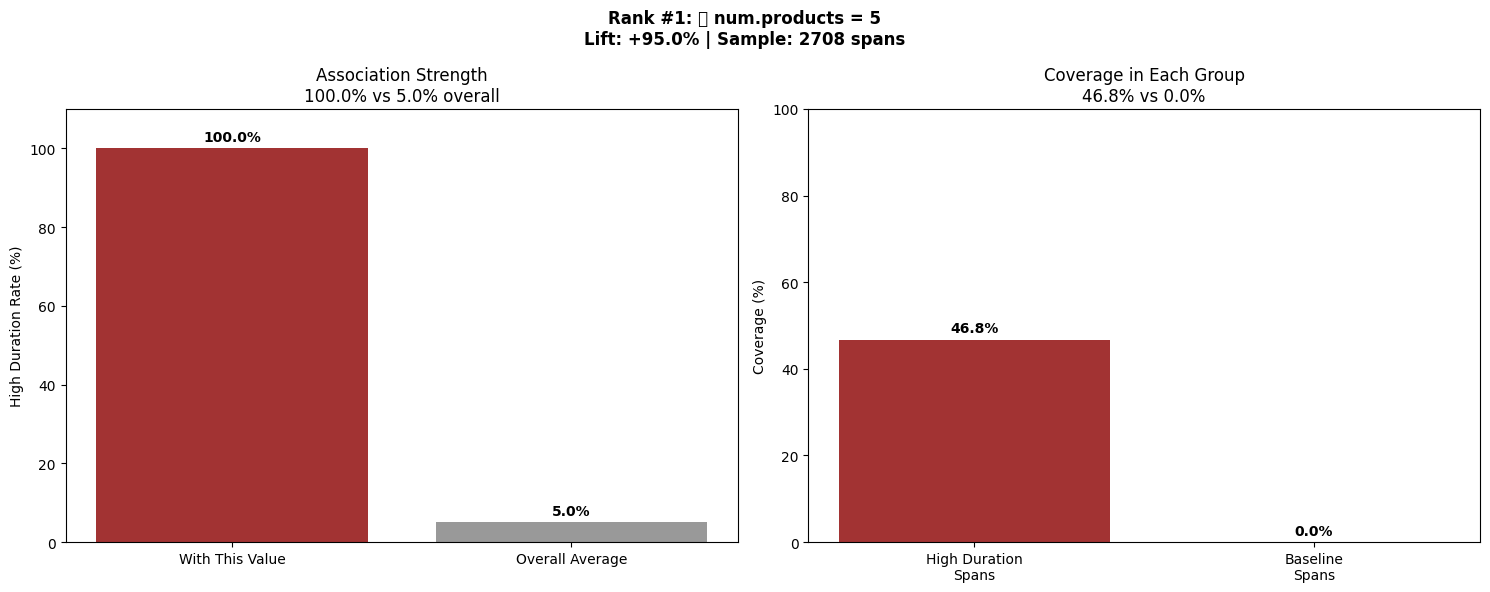

   ✅ Chart created successfully

📋 2. http.method = GET
   Type: Parsed Attribute
   🔴 Association: 96.9% of spans with this value are high duration
   📊 Coverage: 50.3% of high duration spans have this value
   🚀 Lift: +91.9% over expected rate
   🔢 Sample size: 3004 spans
   🎯 Score: 0.816


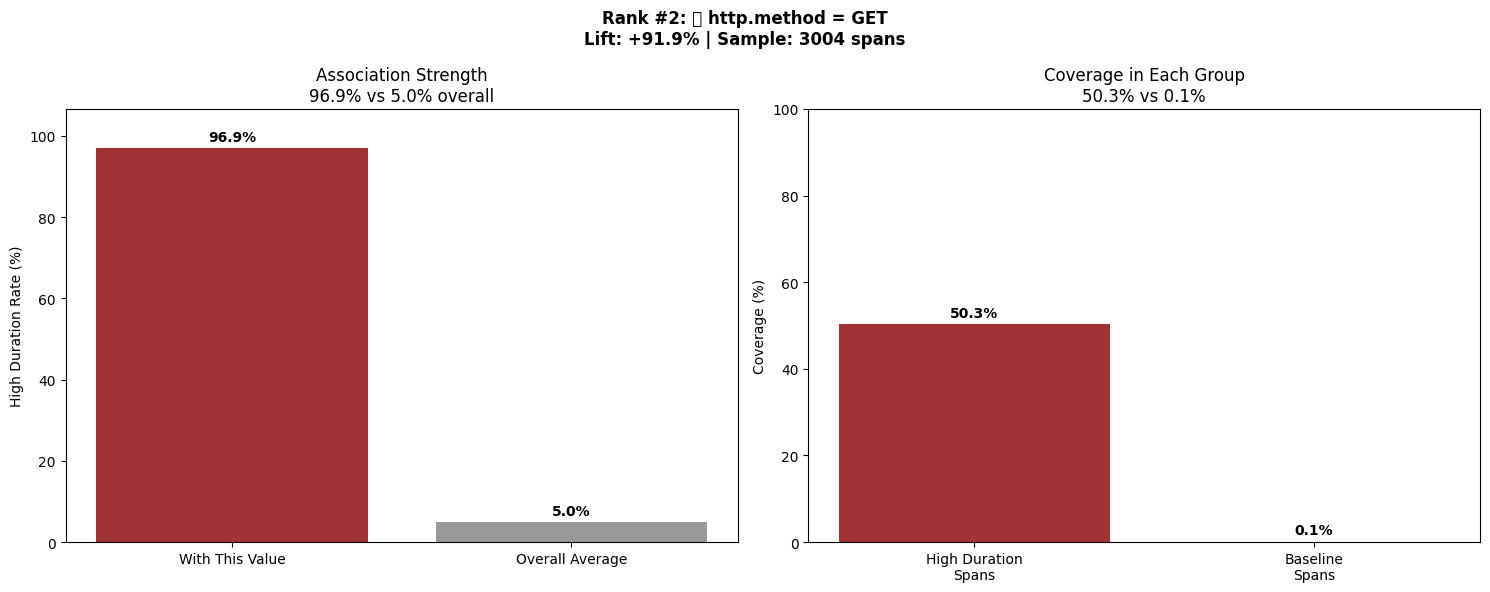

   ✅ Chart created successfully

📋 3. rpc.method = PlaceOrder
   Type: Parsed Attribute
   🔴 Association: 100.0% of spans with this value are high duration
   📊 Coverage: 17.4% of high duration spans have this value
   🚀 Lift: +95.0% over expected rate
   🔢 Sample size: 1006 spans
   🎯 Score: 0.730


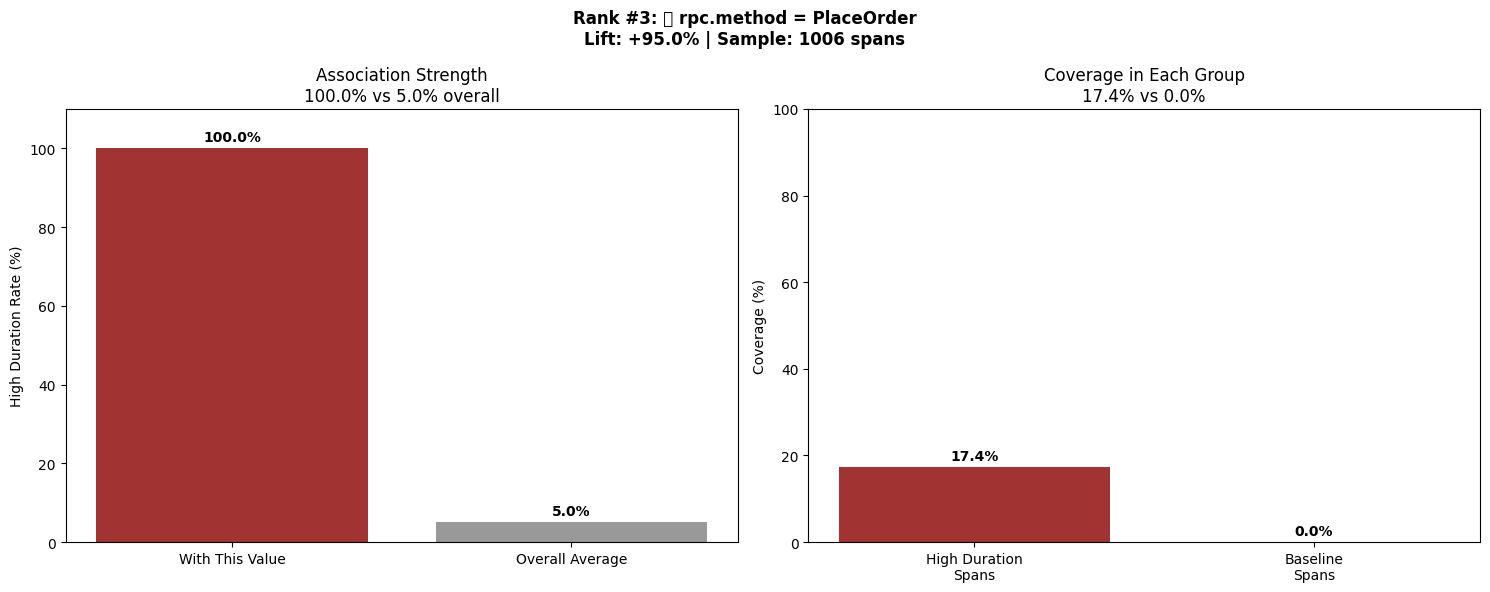

   ✅ Chart created successfully

📋 4. Name = msdemo.CheckoutService/Plac...
   Type: Standard Column
   🔴 Association: 100.0% of spans with this value are high duration
   📊 Coverage: 17.4% of high duration spans have this value
   🚀 Lift: +95.0% over expected rate
   🔢 Sample size: 1006 spans
   🎯 Score: 0.730


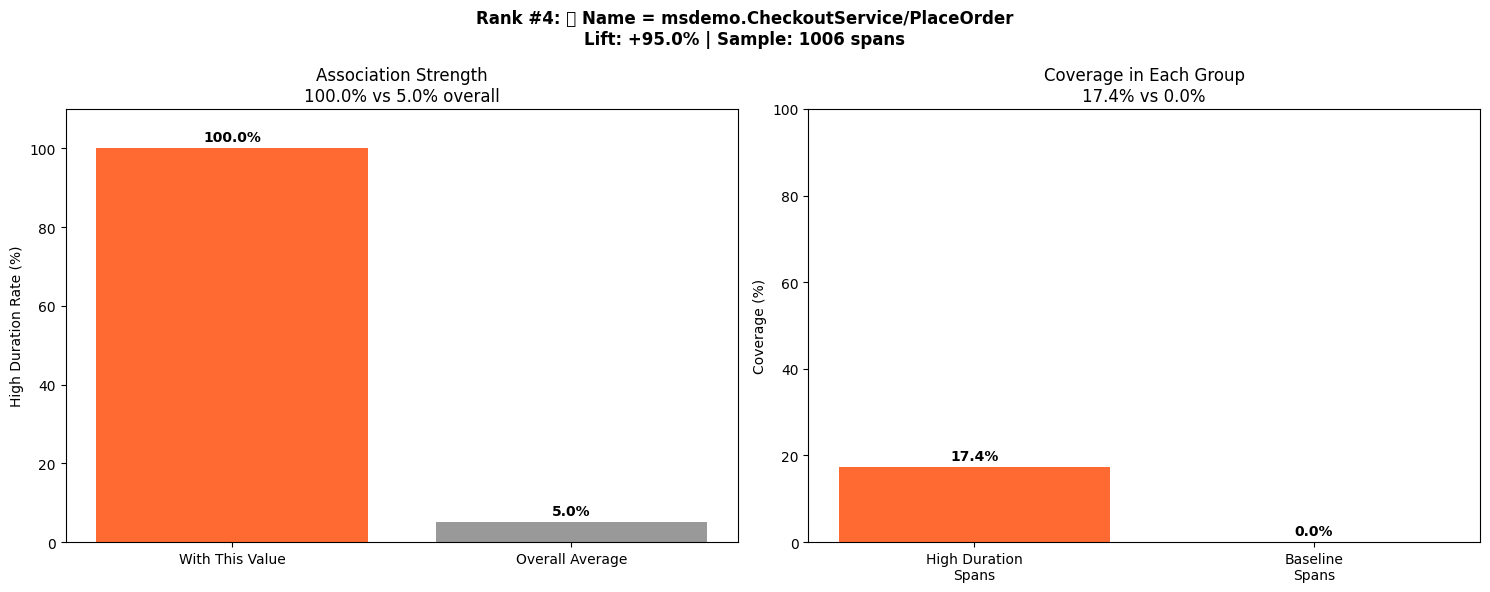

   ✅ Chart created successfully

📋 5. http.route = /product/{id}
   Type: Parsed Attribute
   🔴 Association: 96.5% of spans with this value are high duration
   📊 Coverage: 28.1% of high duration spans have this value
   🚀 Lift: +91.5% over expected rate
   🔢 Sample size: 1685 spans
   🎯 Score: 0.714


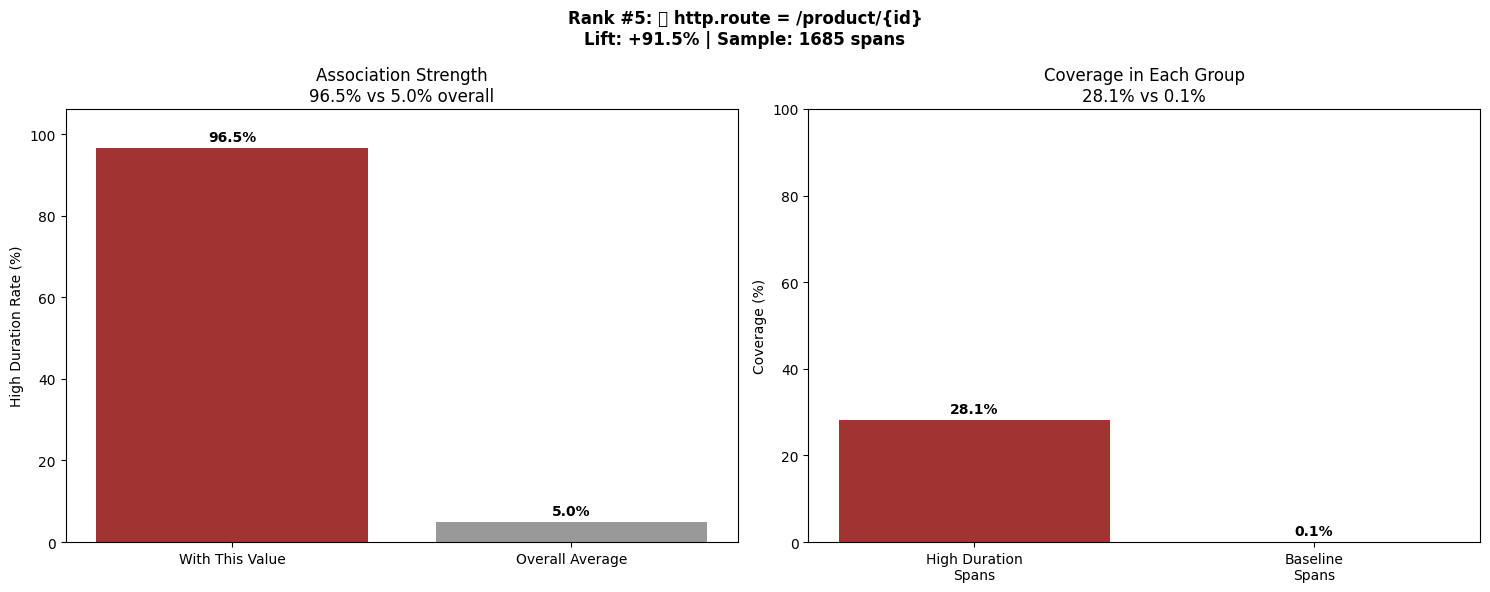

   ✅ Chart created successfully

📋 6. Name = /product/{id}
   Type: Standard Column
   🔴 Association: 96.5% of spans with this value are high duration
   📊 Coverage: 28.1% of high duration spans have this value
   🚀 Lift: +91.5% over expected rate
   🔢 Sample size: 1685 spans
   🎯 Score: 0.714


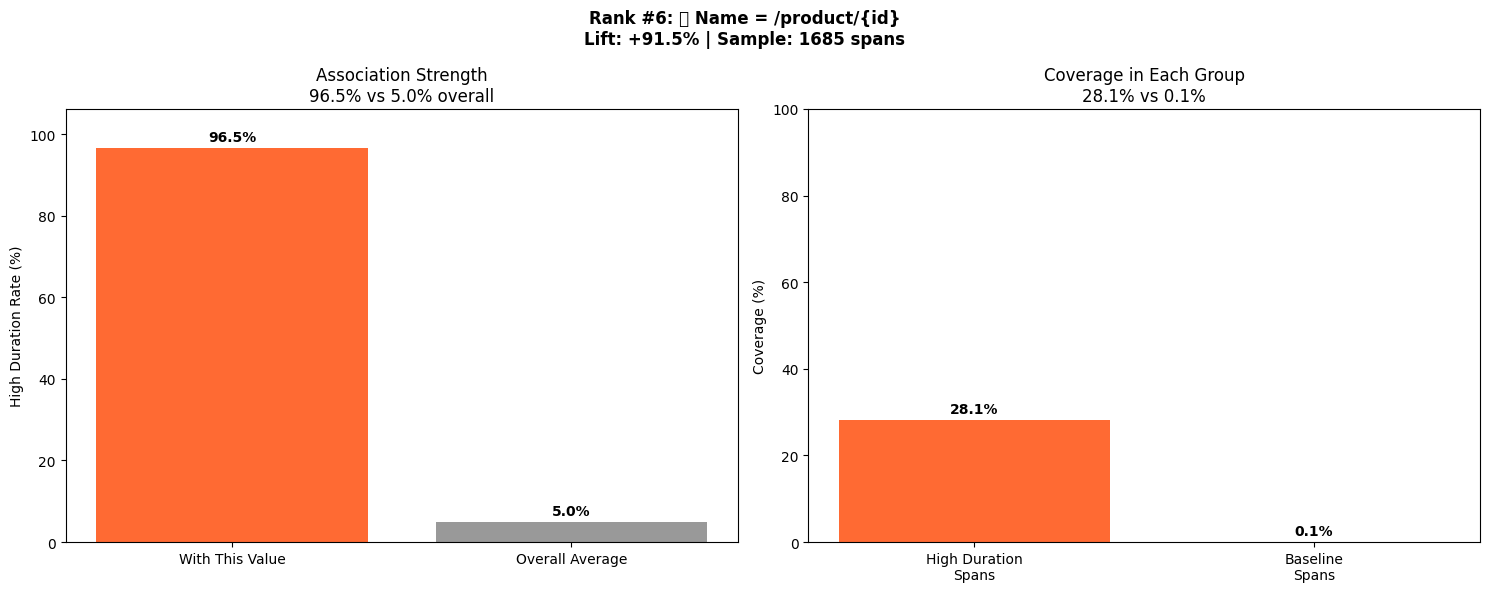

   ✅ Chart created successfully

📋 7. app.build.id = 2e920c4d
   Type: Parsed Attribute
   🔴 Association: 82.2% of spans with this value are high duration
   📊 Coverage: 70.1% of high duration spans have this value
   🚀 Lift: +77.2% over expected rate
   🔢 Sample size: 4943 spans
   🎯 Score: 0.713


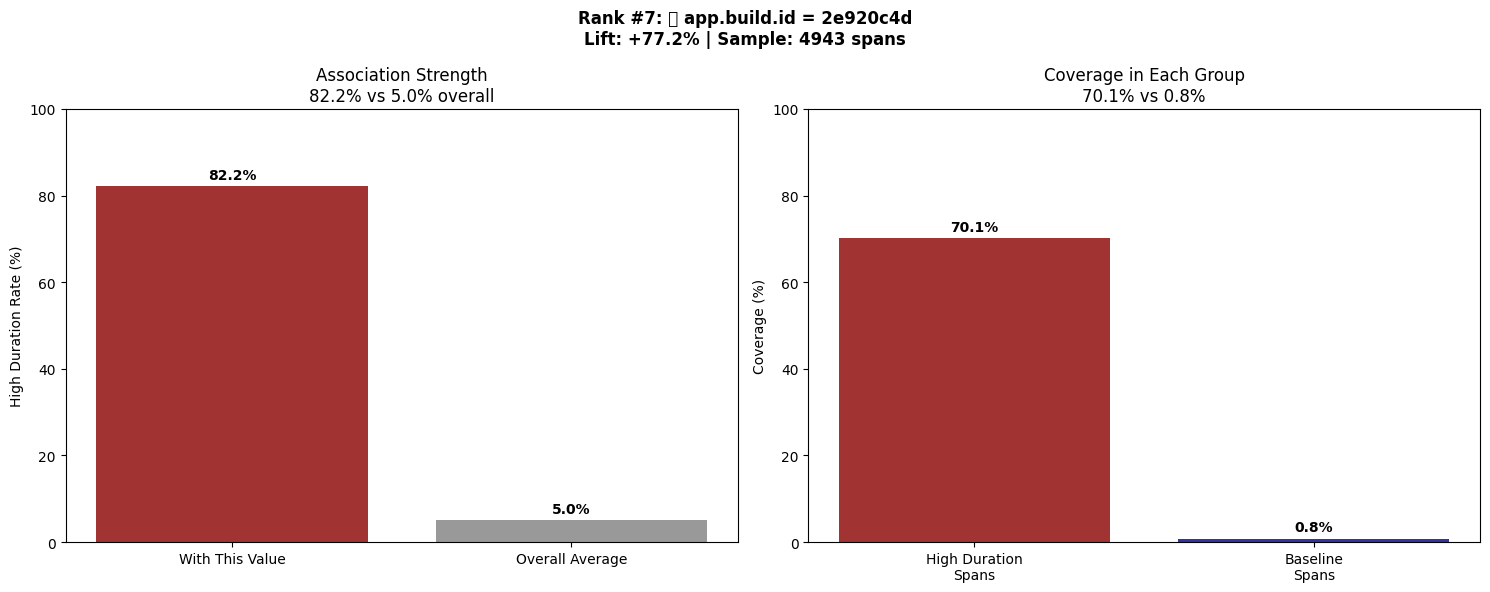

   ✅ Chart created successfully

📋 8. net.host.name = frontend
   Type: Parsed Attribute
   🔴 Association: 80.1% of spans with this value are high duration
   📊 Coverage: 61.4% of high duration spans have this value
   🚀 Lift: +75.1% over expected rate
   🔢 Sample size: 4441 spans
   🎯 Score: 0.684


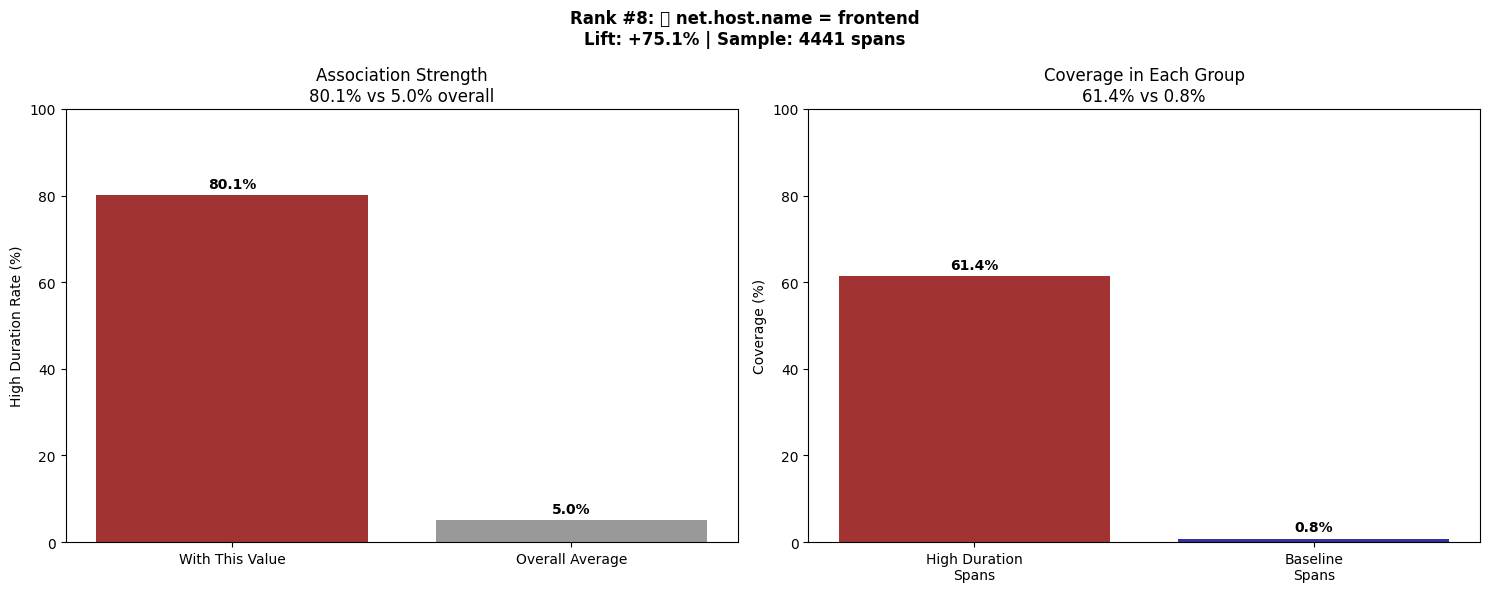

   ✅ Chart created successfully

✅ TOP ATTRIBUTE VALUES ANALYSIS COMPLETE
   📊 Total attribute values available: 68
   📈 Charts created: 8
   ⚠️ Charts skipped: 0
   🎯 Showing top 8 by association strength
   💡 Limited to 8 charts to avoid performance issues

🔍 REMAINING HIGH-VALUE ATTRIBUTE VALUES (not charted):
   9. http.scheme = http
      80.1% association, 61.4% coverage, +75.1% lift
   10. net.protocol.version = 1.1
      80.1% association, 61.4% coverage, +75.1% lift
   11. user.agent.original = python-requests/2.31.0
      80.1% association, 61.4% coverage, +75.1% lift
   12. net.sock.peer.addr = 10.244.2.171
      80.1% association, 61.4% coverage, +75.1% lift
   13. http.target = /cart/checkout
      100.0% association, 8.7% coverage, +95.0% lift
   14. net.sock.peer.port = 5050
      100.0% association, 8.7% coverage, +95.0% lift
   15. http.route = /cart/checkout
      100.0% association, 8.7% coverage, +95.0% lift
   16. Name = /cart/checkout
      100.0% association, 8.7

In [48]:
# Generate comparison graphs for TOP columns ranked by high duration percentage (OPTIMIZED)
print("📊 GENERATING GRAPHS FOR TOP COLUMNS RANKED BY HIGH DURATION PERCENTAGE")
print("=" * 70)

# Check if required variables exist
if 'comparison_groups' not in globals():
    print("❌ Cannot proceed without comparison_groups")
elif 'ranked_attributes' not in globals():
    print("❌ Cannot proceed without ranked_attributes. Please run the ranking cell first.")
else:
    import matplotlib.pyplot as plt
    import seaborn as sns
    from collections import Counter
    import numpy as np

    # Set up the plotting style
    plt.style.use('default')
    sns.set_palette("husl")
    
    print("✅ All required variables are available")
    print(f"📊 Total ranked columns/attributes: {len(ranked_attributes)}")

    def create_attribute_value_chart(value_info):
        """
        Create a chart showing the association between a specific attribute value and high duration spans
        """
        display_name = value_info[0]
        metadata = value_info[2]
        column_name = metadata['column_name']
        attribute_value = metadata['attribute_value']
        column_type = metadata['column_type']
        
        # Get high duration and baseline groups
        high_group = comparison_groups['high_duration']
        baseline_group = comparison_groups['baseline']
        
        # Count spans with and without this specific value
        high_with_value = (high_group[column_name] == attribute_value).sum()
        high_without_value = len(high_group) - high_with_value
        baseline_with_value = (baseline_group[column_name] == attribute_value).sum()
        baseline_without_value = len(baseline_group) - baseline_with_value
        
        if high_with_value == 0 and baseline_with_value == 0:
            return None
            
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # Chart 1: Association strength (what % of spans with this value are high duration)
        total_with_value = high_with_value + baseline_with_value
        if total_with_value > 0:
            high_rate_with_value = (high_with_value / total_with_value) * 100
        else:
            high_rate_with_value = 0
            
        # Compare to overall high duration rate
        total_spans = len(high_group) + len(baseline_group)
        overall_high_rate = (len(high_group) / total_spans) * 100
        
        # Create comparison bars
        categories = ['With This Value', 'Overall Average']
        rates = [high_rate_with_value, overall_high_rate]
        colors = ['darkred' if column_type == "Parsed Attribute" else 'orangered', 'gray']
        
        bars1 = ax1.bar(categories, rates, color=colors, alpha=0.8)
        ax1.set_ylabel('High Duration Rate (%)')
        ax1.set_title(f'Association Strength\n{high_rate_with_value:.1f}% vs {overall_high_rate:.1f}% overall')
        ax1.set_ylim(0, max(100, max(rates) * 1.1))
        
        # Add value labels on bars
        for bar, rate in zip(bars1, rates):
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
                    f'{rate:.1f}%', ha='center', va='bottom', fontweight='bold')
        
        # Chart 2: Coverage (how much of each group has this value)
        high_coverage = (high_with_value / len(high_group)) * 100 if len(high_group) > 0 else 0
        baseline_coverage = (baseline_with_value / len(baseline_group)) * 100 if len(baseline_group) > 0 else 0
        
        groups = ['High Duration\nSpans', 'Baseline\nSpans']
        coverages = [high_coverage, baseline_coverage]
        colors2 = ['darkred' if column_type == "Parsed Attribute" else 'orangered', 
                  'darkblue' if column_type == "Parsed Attribute" else 'steelblue']
        
        bars2 = ax2.bar(groups, coverages, color=colors2, alpha=0.8)
        ax2.set_ylabel('Coverage (%)')
        ax2.set_title(f'Coverage in Each Group\n{high_coverage:.1f}% vs {baseline_coverage:.1f}%')
        ax2.set_ylim(0, max(100, max(coverages) * 1.1))
        
        # Add value labels on bars
        for bar, coverage in zip(bars2, coverages):
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + 1,
                    f'{coverage:.1f}%', ha='center', va='bottom', fontweight='bold')
        
        # Overall title
        type_indicator = "🏷️" if column_type == "Parsed Attribute" else "📋"
        # Truncate long attribute values for title
        value_str = str(attribute_value)
        if len(value_str) > 50:
            value_str = value_str[:47] + "..."
        
        suptitle = f'{type_indicator} {metadata["attribute_name"]} = {value_str}\n'
        suptitle += f'Lift: {metadata["lift"]:+.1f}% | Sample: {metadata["total_with_value"]} spans'
        fig.suptitle(suptitle, fontsize=12, fontweight='bold')
        
        plt.tight_layout()
        return fig

    # Show summary of what we're analyzing
    attr_count = sum(1 for _, _, meta in ranked_attributes if meta['column_type'] == "Parsed Attribute")
    std_count = len(ranked_attributes) - attr_count
    
    print(f"\n📈 AVAILABLE FOR ANALYSIS:")
    print(f"   📋 Standard Column Values: {std_count}")
    print(f"   🏷️  Parsed Attribute Values: {attr_count}")
    print(f"   📊 Total: {len(ranked_attributes)}")
    
    # LIMIT to top 8 only to avoid infinite loops
    MAX_CHARTS = 8
    print(f"\n💡 Generating charts for TOP {MAX_CHARTS} attribute values only...")
    print("=" * 70)

    # Generate graphs for top attribute values (LIMITED)
    figures_created = 0
    skipped_count = 0
    
    for i, value_info in enumerate(ranked_attributes[:MAX_CHARTS], 1):
        display_name, score, metadata = value_info
        
        print(f"\n📋 {i}. {display_name}")
        print(f"   Type: {metadata['column_type']}")
        print(f"   🔴 Association: {metadata['association_strength']:.1f}% of spans with this value are high duration")
        print(f"   📊 Coverage: {metadata['high_coverage']:.1f}% of high duration spans have this value")
        print(f"   🚀 Lift: {metadata['lift']:+.1f}% over expected rate")
        print(f"   🔢 Sample size: {metadata['total_with_value']} spans")
        print(f"   🎯 Score: {metadata['importance_score']:.3f}")
        
        try:
            fig = create_attribute_value_chart(value_info)
            
            if fig is not None:
                # Add ranking info to title
                current_title = fig._suptitle.get_text() if fig._suptitle else ""
                new_title = f"Rank #{i}: {current_title}"
                fig.suptitle(new_title, fontsize=12, fontweight='bold')
                
                plt.show()
                figures_created += 1
                print(f"   ✅ Chart created successfully")
            else:
                print(f"   ⚠️ Skipped - no useful data to display")
                skipped_count += 1
        except Exception as e:
            print(f"   ❌ Error creating chart: {str(e)[:100]}...")
            skipped_count += 1
            continue

    print(f"\n✅ TOP ATTRIBUTE VALUES ANALYSIS COMPLETE")
    print(f"   📊 Total attribute values available: {len(ranked_attributes)}")
    print(f"   📈 Charts created: {figures_created}")
    print(f"   ⚠️ Charts skipped: {skipped_count}")
    print(f"   🎯 Showing top {MAX_CHARTS} by association strength")
    print(f"   💡 Limited to {MAX_CHARTS} charts to avoid performance issues")
    
    if len(ranked_attributes) > MAX_CHARTS:
        print(f"\n🔍 REMAINING HIGH-VALUE ATTRIBUTE VALUES (not charted):")
        for i, (name, score, meta) in enumerate(ranked_attributes[MAX_CHARTS:MAX_CHARTS+10], MAX_CHARTS+1):
            short_name = name[:50] + "..." if len(name) > 53 else name
            print(f"   {i}. {short_name}")
            print(f"      {meta['association_strength']:.1f}% association, {meta['high_coverage']:.1f}% coverage, {meta['lift']:+.1f}% lift")